In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

!pwd
import os
os.chdir('/content/drive/My Drive/Colab Notebooks')
!pwd
# Get the current working directory
current_directory = os.getcwd()

# Specify the file name
file_name = "mastershifted.txt"

# Construct the full path to the file
file_path = os.path.join(current_directory, file_name)

# Open the file
try:
    with open(file_path, "r") as f:
        # Do something with the file (e.g., print its contents)
        print("Loaded successfully")
except FileNotFoundError:
    print(f"The file '{file_name}' was not found in the current directory.")
except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
#Import the necessary modules
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Reshape, LSTM, Dense, Dropout, Activation, TimeDistributed, Flatten, BatchNormalization, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [ ]:
#Read the data variables

colnames=( 'Bx', 'By', 'Bz', 'Vx', 'Density', 'Labels')
df = pd.read_csv('mastershifted.txt', sep='\s+', names=colnames)
dfc=df.drop(['Labels'], axis=1)

In [1]:

#We have 120 minute windows, each associated with either a 1 or 0
n_timesteps = 120

Xcols=[x for x in dfc.columns if x!= 'Labels']
n_features=len(Xcols)
model= Sequential()
#We use a scaler that does not standardize/normalize the values because we do not expect Gaussian data
scaler = MinMaxScaler()
X = df[Xcols].values
y=df['Labels']

NameError: name 'dfc' is not defined

In [ ]:
#We need to use 70/15/15 for train/test/validate
#The samples are 120 rows by 6 variables. We need to specify the indices of each sample and then multiple by 120

targtrain=np.empty((53404,))
targtrain[::2]=0 #BE VERY CAREFUL WITH THE 1S AND OS in [::2] and [1::2]
targtrain[1::2]=1 #BE VERY CAREFUL WITH THE 1S AND OS in [::2] and [1::2]

targtest=np.empty((11444,))
targtest[::2]=0 #BE VERY CAREFUL WITH THE 1S AND OS in [::2] and [1::2]
targtest[1::2]=1 #BE VERY CAREFUL WITH THE 1S AND OS in [::2] and [1::2]

targvalid=np.empty((11444,))
targvalid[::2]=0 #BE VERY CAREFUL WITH THE 1S AND OS in [::2] and [1::2]
targvalid[1::2]=1 #BE VERY CAREFUL WITH THE 1S AND OS in [::2] and [1::2]

In [2]:
#The last column has 0s or 1s only for each sample (substorm or non substorm)
#These are all the row locations for each data set to be used.
X_train = X[0:6408480]
y_train = targtrain#y[0:4700760]
X_test =  X[6408480:7781760]
y_test =  targtest#y[4700760:5708040]
X_val =   X[7781760:9155040]
y_val =   targvalid#y[5708040:6715320]

NameError: name 'X' is not defined

In [ ]:
#This is for Conv2D. Do not change it.
#We use the scaler on each set of data based on its maximum and minimum to make computation easier
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val=scaler.transform(X_val)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
418/418 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4981 - loss: 0.6966 - val_accuracy: 0.5018 - val_loss: 0.6867
Epoch 2/150
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5648 - loss: 0.6859 - val_accuracy: 0.5801 - val_loss: 0.6767
Epoch 3/150
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6275 - loss: 0.6767 - val_accuracy: 0.6818 - val_loss: 0.6629
Epoch 4/150
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6787 - loss: 0.6627 - val_accuracy: 0.7517 - val_loss: 0.6449
Epoch 5/150
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7070 - loss: 0.6471 - val_accuracy: 0.7643 - val_loss: 0.6247
Epoch 6/150
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7274 - loss: 0.6289 - val_accuracy: 0.7780 - val_loss: 0.6055
Epoch 7/150
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7382 - loss: 0.6115 - val_accuracy: 0.7810 - val_loss: 0.5862
Epoch 8/150
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7424 - loss: 0.5937 - val_acc

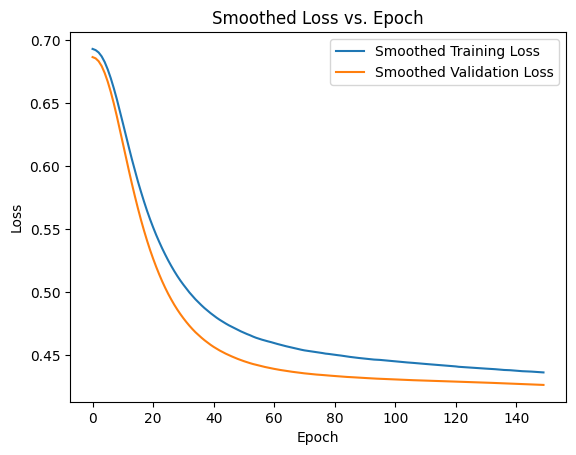

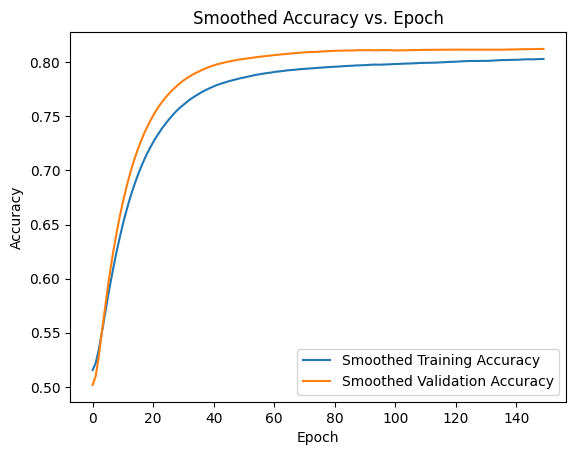

ROC AUC: 0.8746513575948947


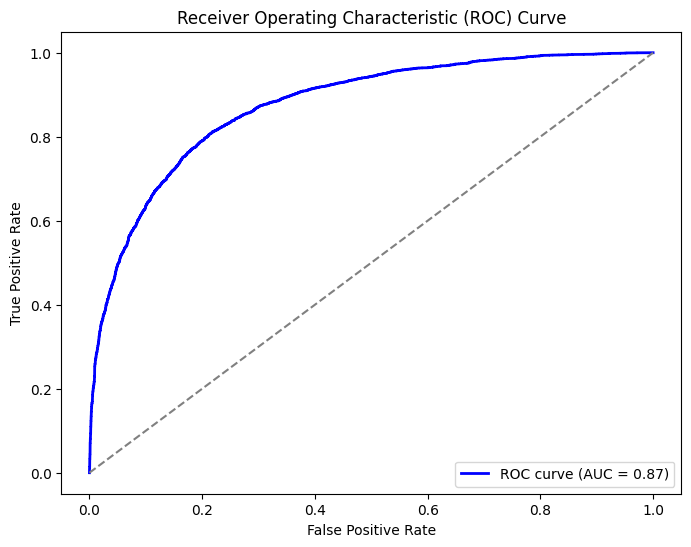

In [ ]:
n_samples = int(X_train.shape[0]/120)
X_tr = np.resize(X_train, (n_samples, n_timesteps, n_features, 1))
X_te = np.resize(X_test, (11444, 120, 5, 1))
X_va = np.resize(X_val, (11444, 120, 5, 1))

model = Sequential()

# First Conv2D layer: Apply 32 filters of size 3x3, with ReLU activation, and input shape (120, 5, 1)
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(120, 5, 1)))



model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))

# MaxPooling to downsample the feature maps
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))  ##

# Flatten the 2D feature maps to 1D vector
model.add(Flatten())

# Fully connected layer with 128 neurons and ReLU activation
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))##

# Output layer: 1 neuron, sigmoid activation for binary classification
model.add(Dense(1, activation='sigmoid'))

# Step 4: Compile the model
model.compile(optimizer=Adam(learning_rate=0.000001), loss='binary_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
history=model.fit(X_tr, y_train, epochs=90, batch_size=128, validation_data=(X_va, y_val))


In [ ]:
from sklearn.metrics import confusion_matrix

#[[TN, FP]
#[FN, TP]]
cm = confusion_matrix(y_test, predicted_labels_test)
print("Confusion matrix:\n",cm)

Confusion matrix:
 [[4783  939]
 [1443 4279]]
